Auto-adjusting View: X[-0.34, 1.44], Y[-0.46, 0.82]


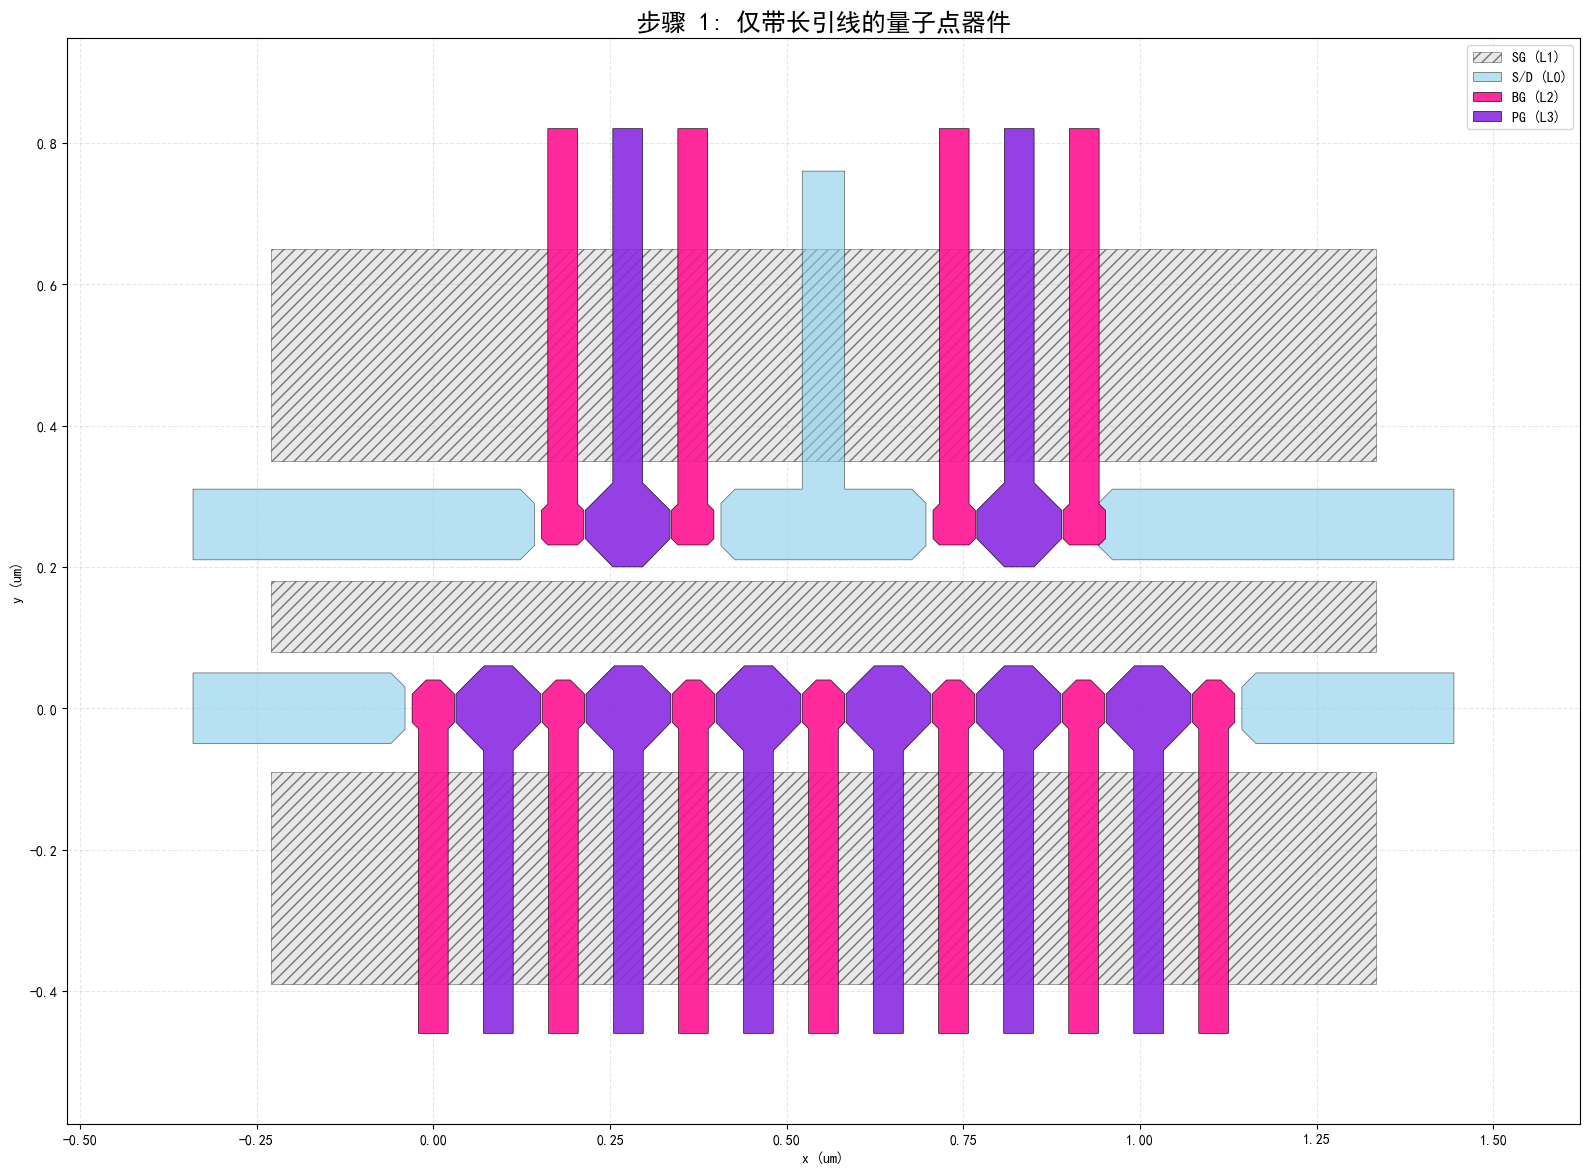

--- 步骤 2: 仅带引线的焊盘框架 ---
正在可视化: 步骤 2: 仅带引线的焊盘框架...


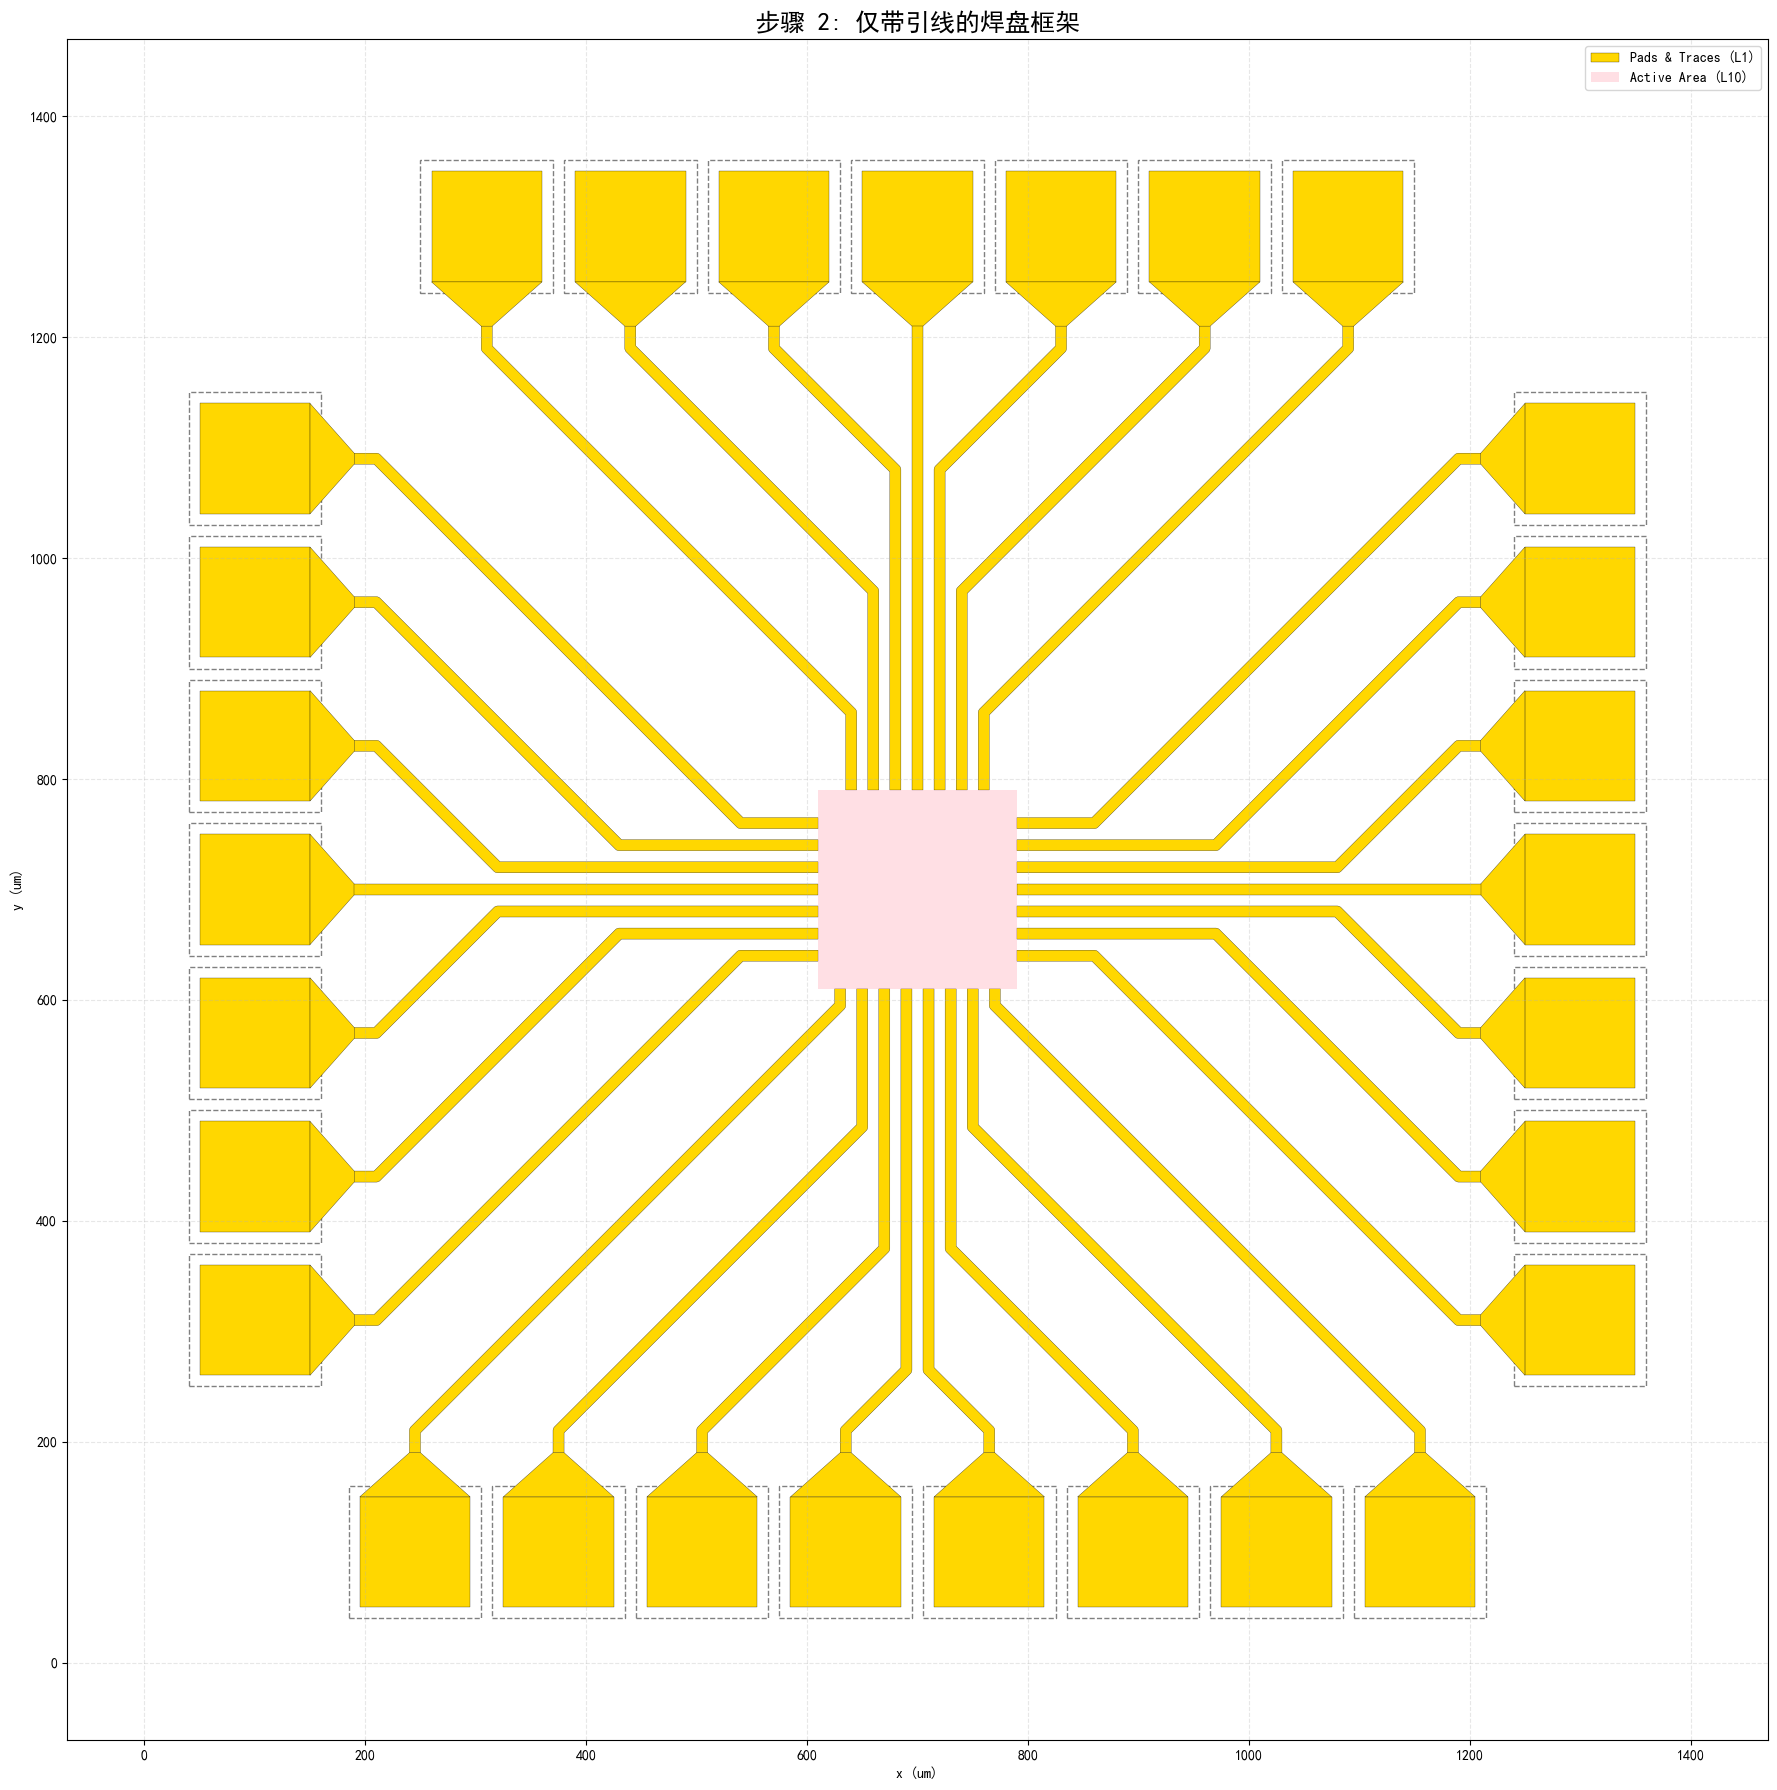

GDS 文件已保存到: 'step2_pad_frame.gds'

--- 步骤 3: 器件已放置 (未布线) ---
正在可视化: 步骤 3: 器件已放置 (未布线)...


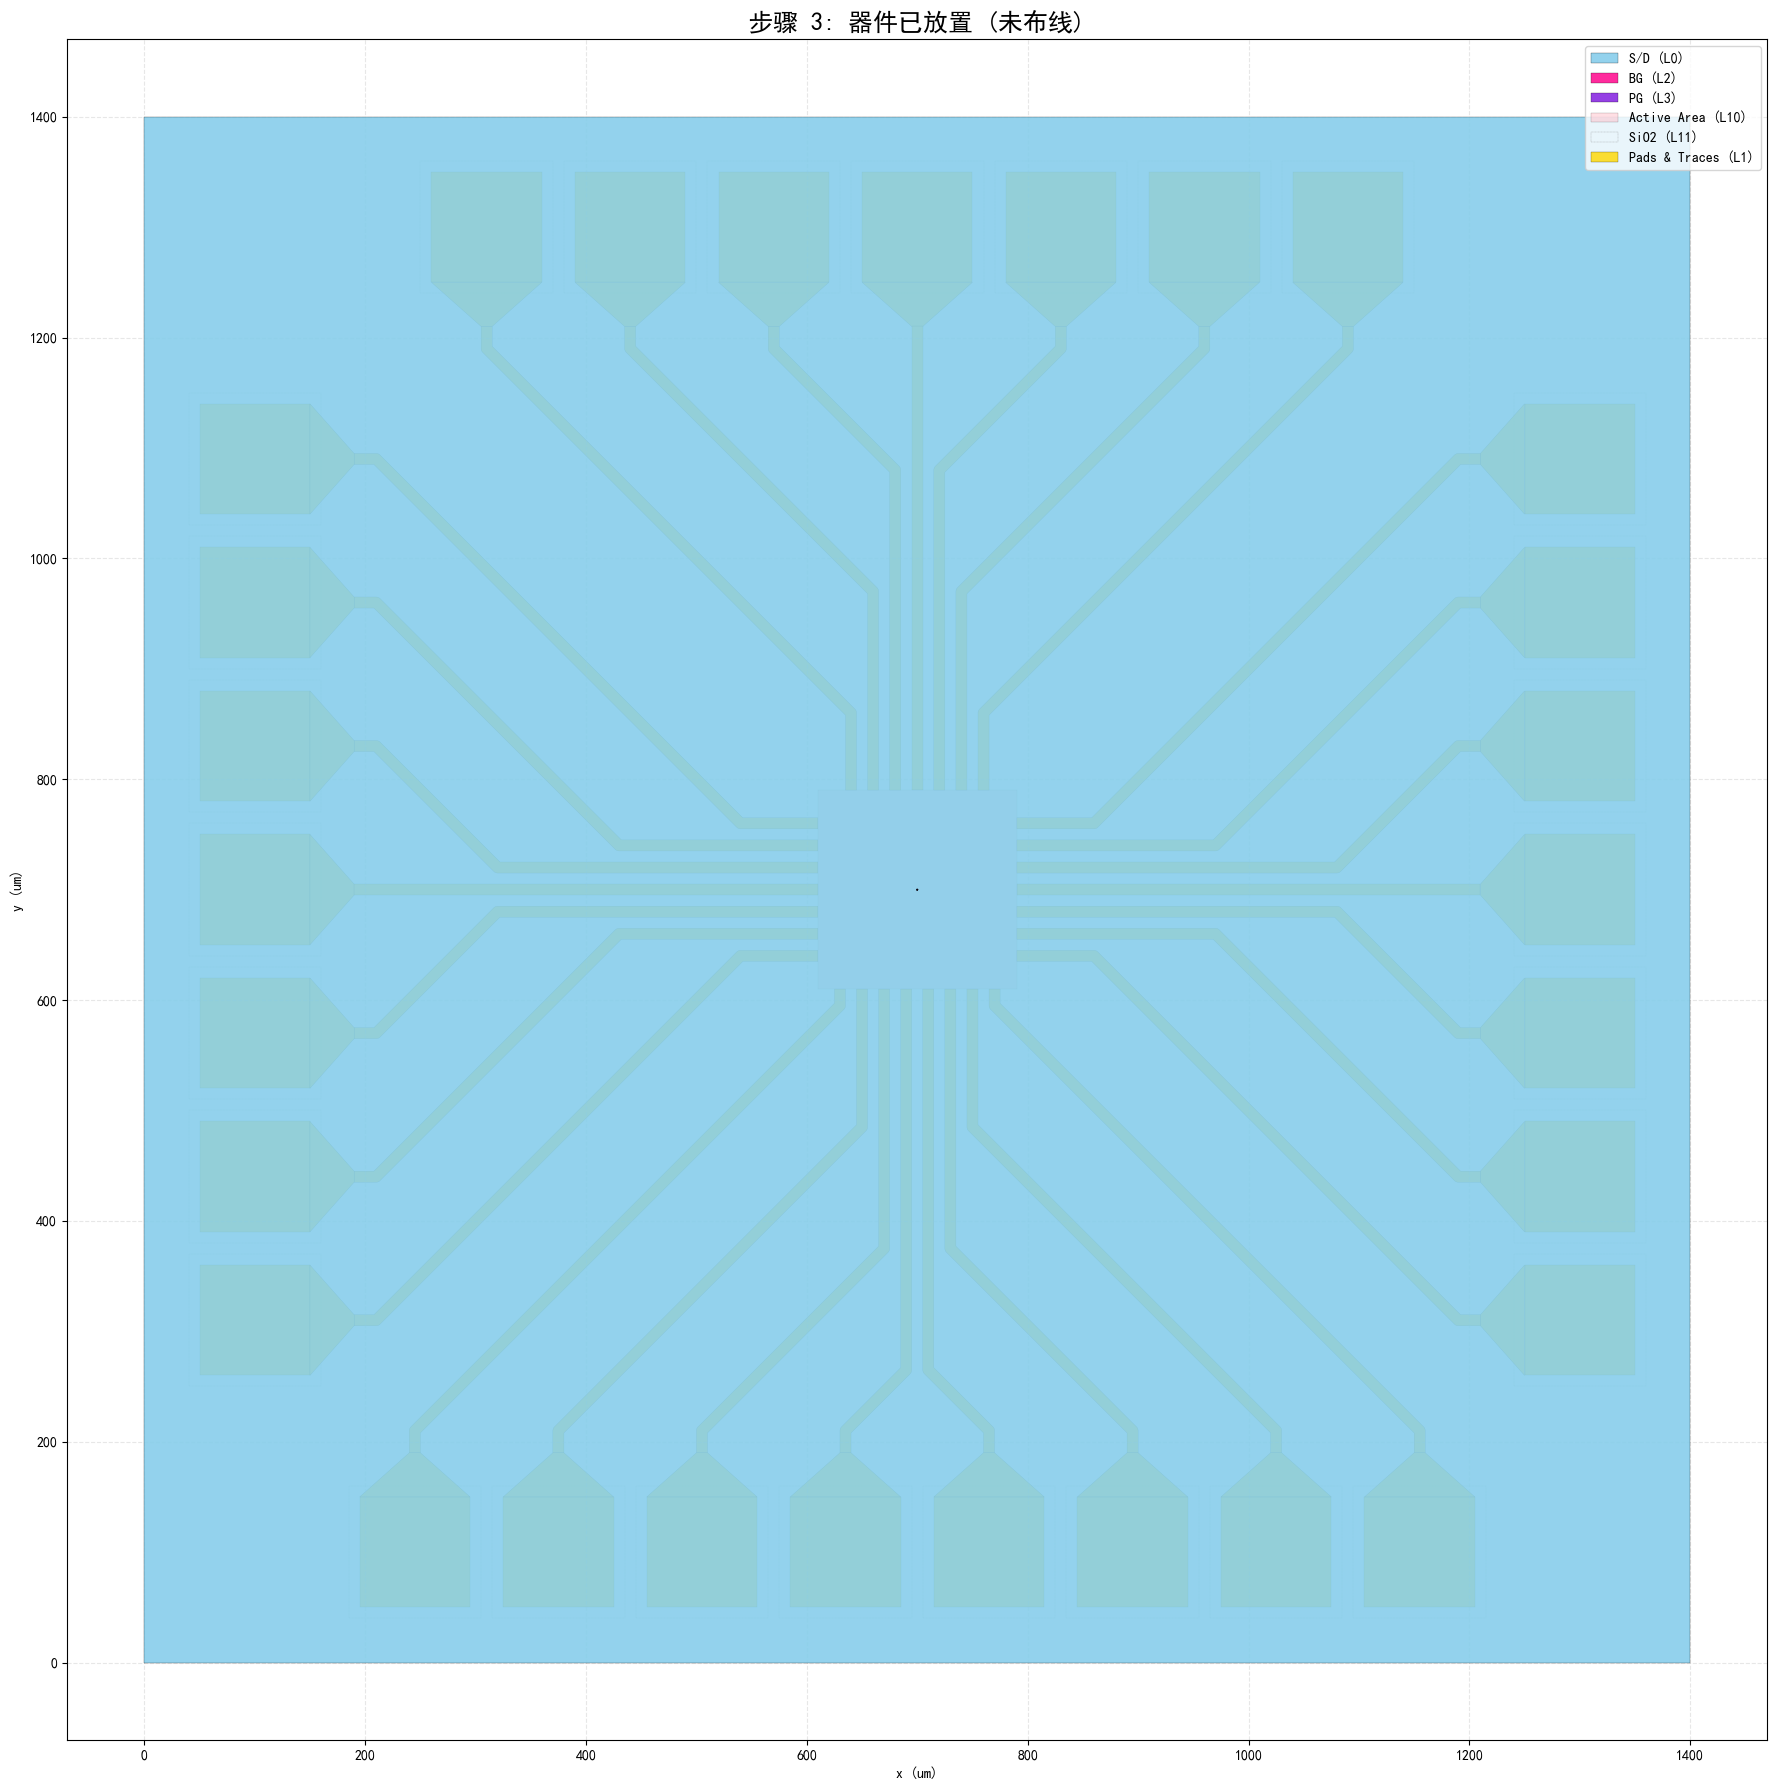

GDS 文件已保存到: 'step3_placed_unrouted.gds'

--- 步骤 4: 连接单条线 (QD_PG4) ---
正在可视化: 步骤 4: 连接单条线 (QD_PG4)...


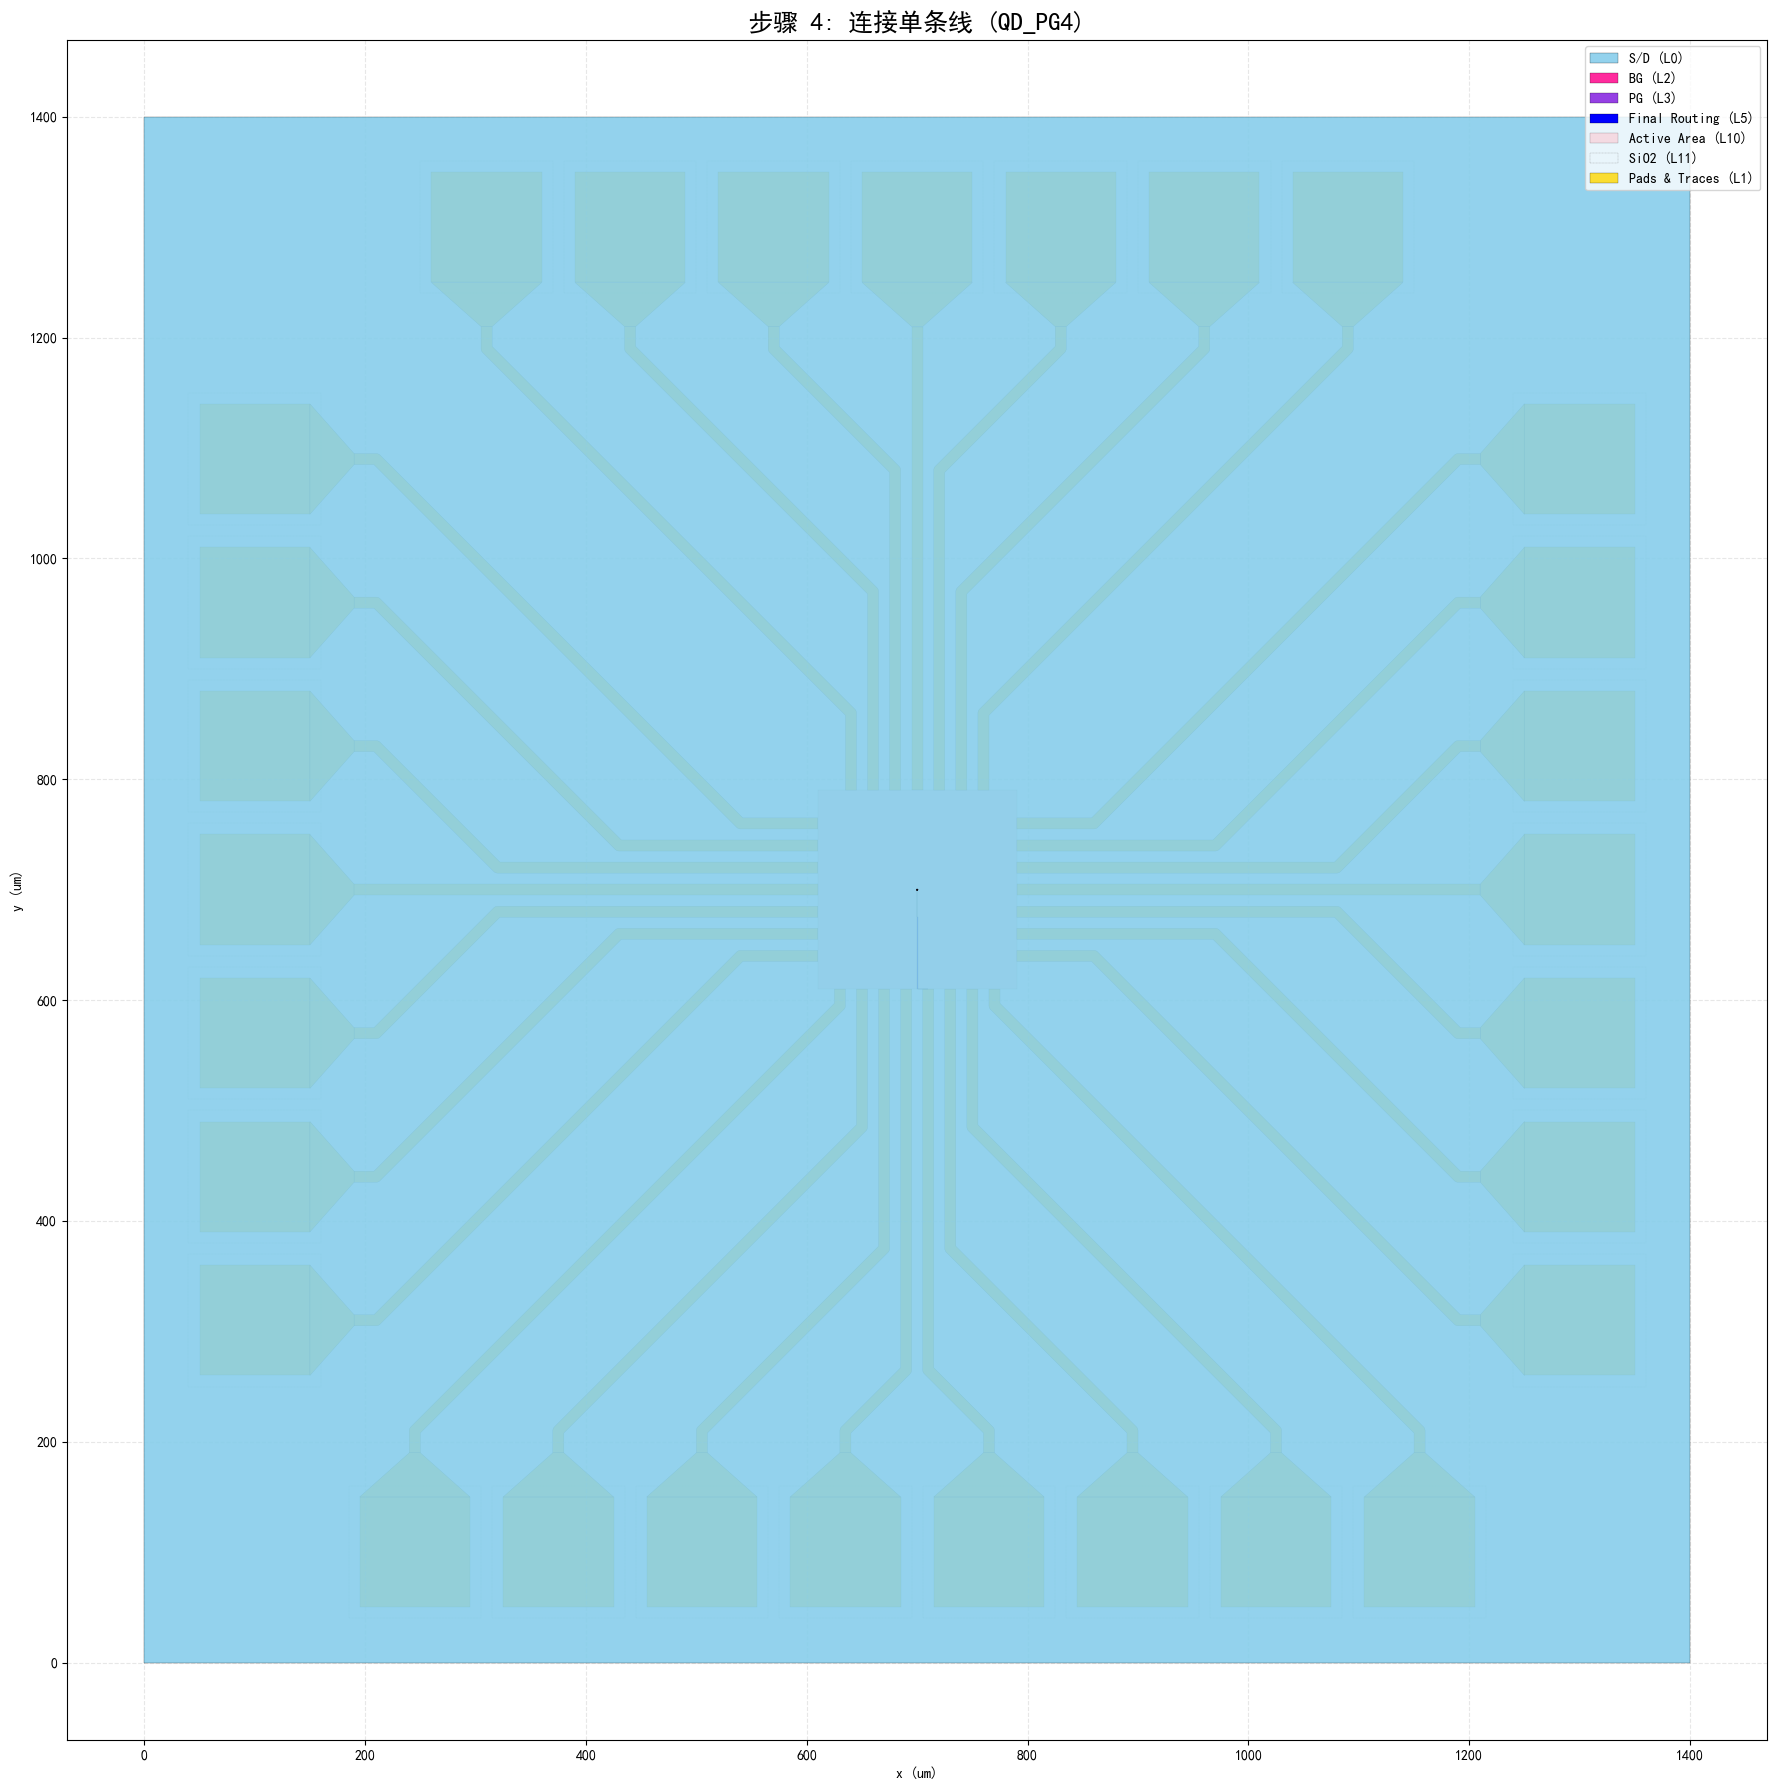

GDS 文件已保存到: 'step4_single_route.gds'

--- 步骤 5: 最终完整布线 ---
正在可视化: 步骤 5: 最终完整布线...


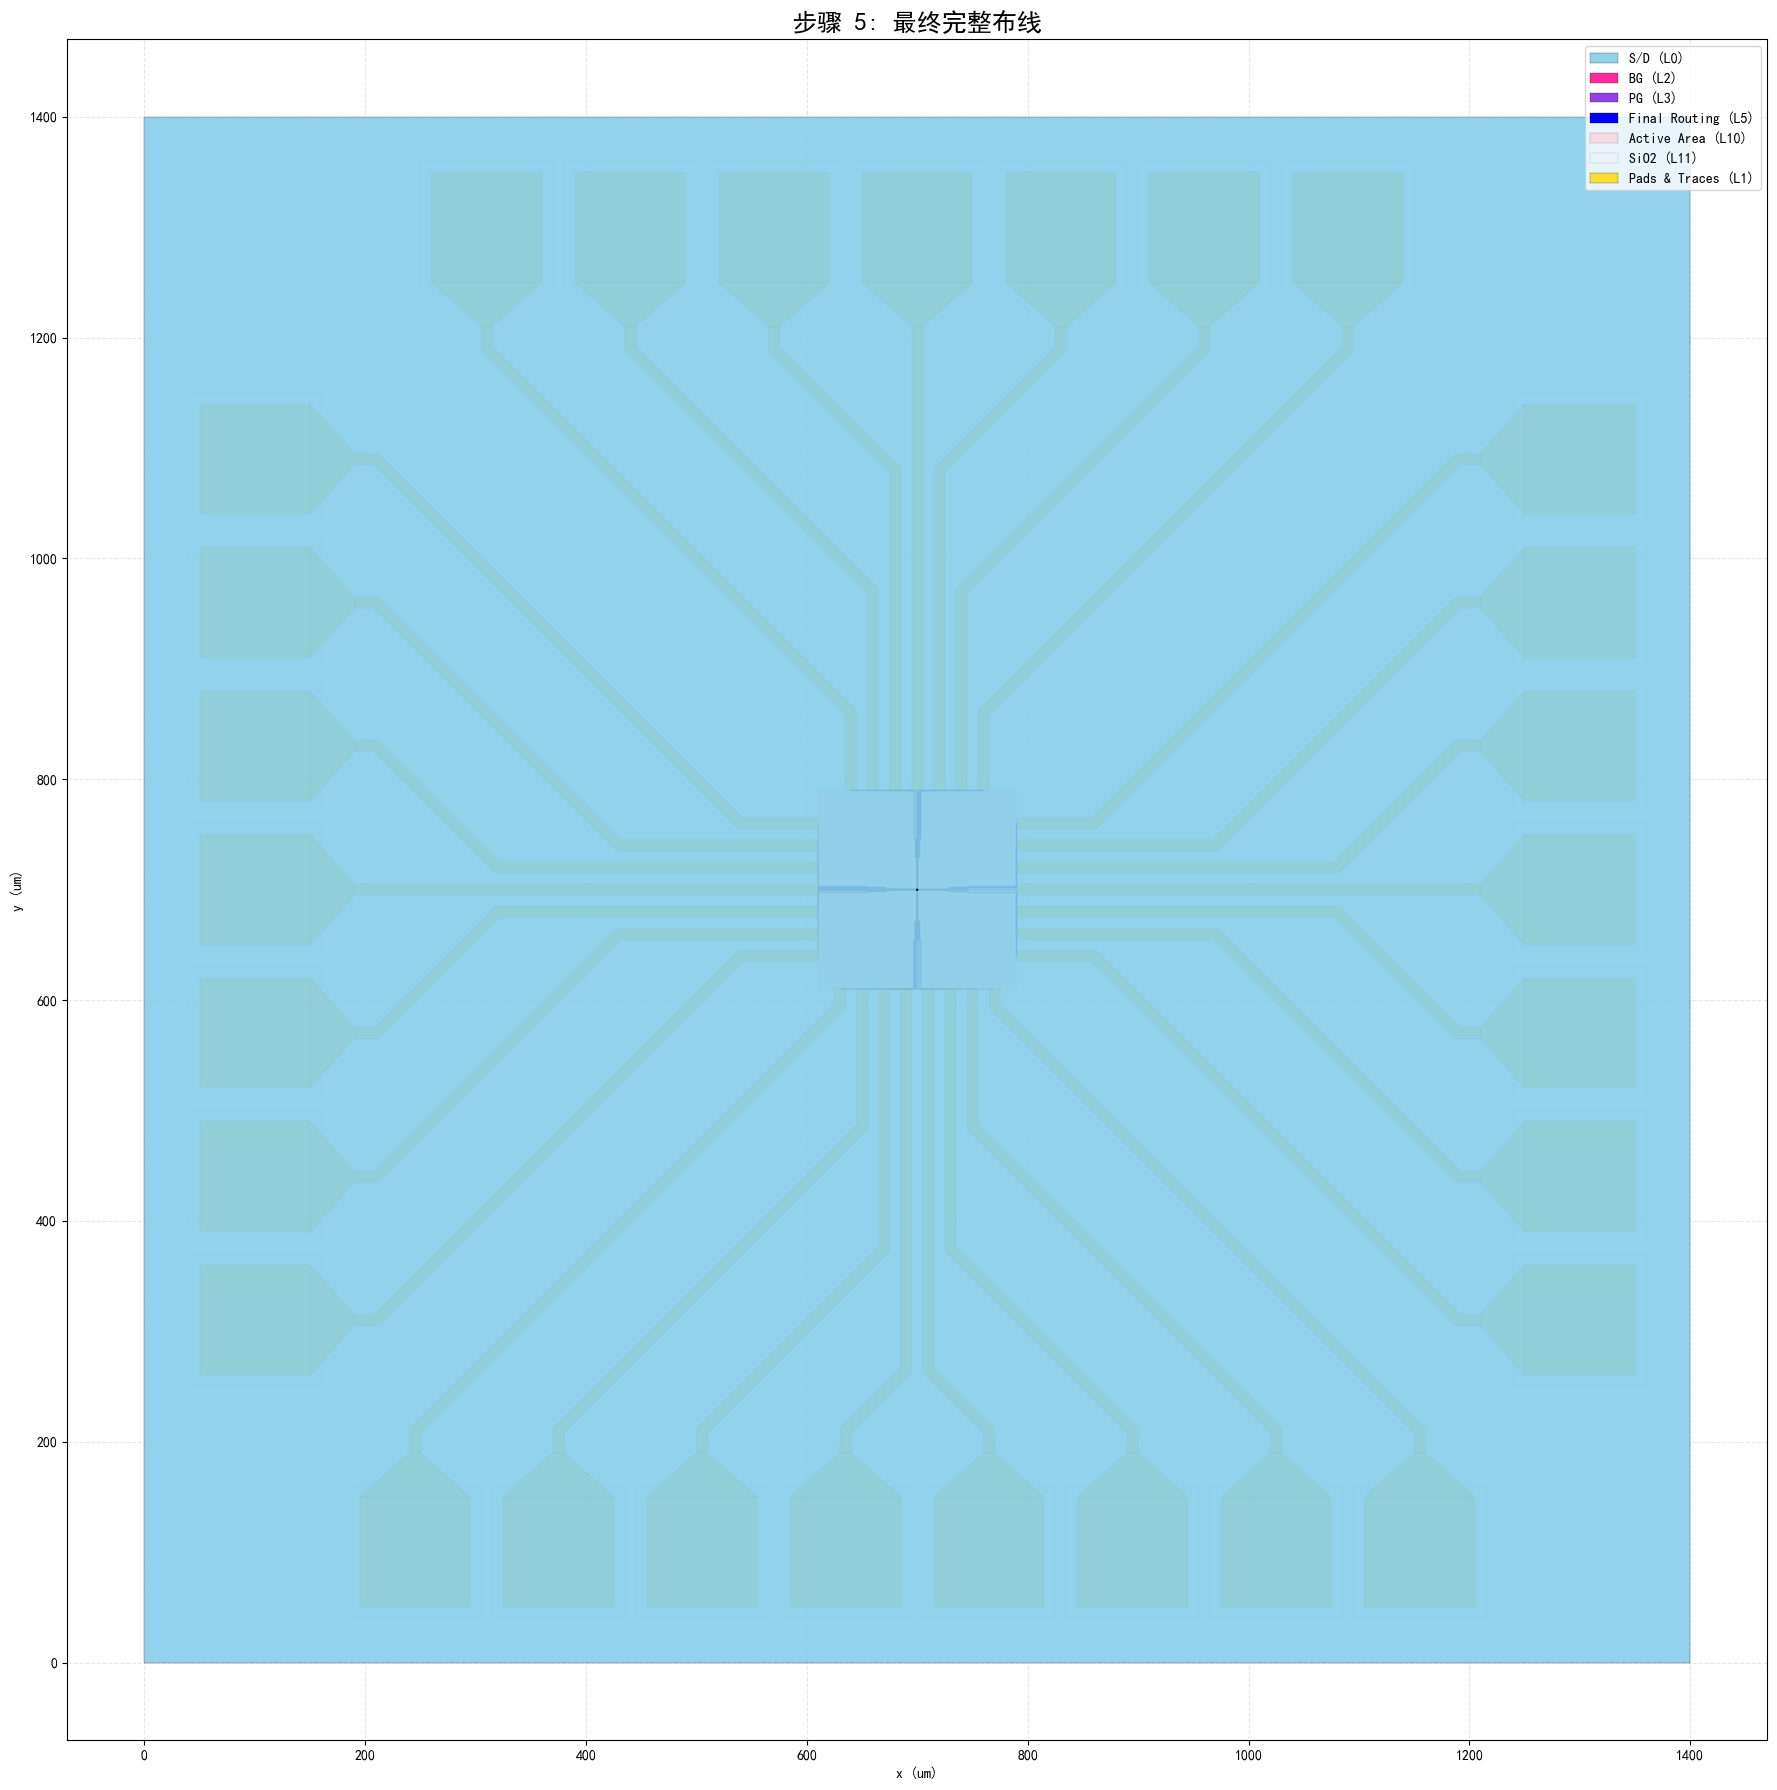

GDS 文件已保存到: 'step5_fully_routed.gds'

全部分步流程执行完毕！


In [10]:
# ===================================================================
#                      用户提供的代码基础 (不可删减)
# ===================================================================

import gdstk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.patches as patches
import math
import re

# ===================================================================
#                      解决中文显示问题的代码
# ===================================================================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# ===================================================================

# --- User-Provided Functions (plot_gds, create_6qd_layout_with_labels, create_rect_wire_layout) ---
# ... (These functions are kept exactly as you provided them in the previous step) ...
def plot_gds(cell, title="量子点器件布局"):
    fig, ax = plt.subplots(figsize=(16, 12)); ax.set_title(title, fontsize=18)
    layer_config = {0:{'color':'#87CEEB','alpha':0.6,'label':'S/D (L0)','zorder':2}, 1:{'color':'#D3D3D3','alpha':0.5,'label':'SG (L1)','hatch':'///','zorder':1}, 2:{'color':'#FF1493','alpha':0.9,'label':'BG (L2)','zorder':3}, 3:{'color':'#8A2BE2','alpha':0.9,'label':'PG (L3)','zorder':4}}
    drawn_labels = set()
    for layer in [1, 0, 2, 3]: 
        polygons = cell.get_polygons(layer=layer, datatype=0)
        if not polygons: continue
        cfg = layer_config.get(layer); label = cfg['label']
        for gds_poly in polygons:
            pts = gds_poly.points
            if pts.ndim != 2 or len(pts) < 3: continue
            current_label = label if label not in drawn_labels else None
            poly = MplPolygon(pts, closed=True, facecolor=cfg['color'], edgecolor='black', linewidth=0.5, alpha=cfg['alpha'], hatch=cfg.get('hatch', ''), label=current_label, zorder=cfg['zorder'])
            ax.add_patch(poly); drawn_labels.add(label)
    handles, labels = ax.get_legend_handles_labels()
    if handles: by_label = dict(zip(labels, handles)); ax.legend(by_label.values(), by_label.keys(), loc='upper right')
    ax.set_aspect('equal')
    bbox = cell.bounding_box()
    if bbox is not None:
        min_x, min_y = bbox[0]; max_x, max_y = bbox[1]; width = max_x - min_x; height = max_y - min_y; margin_x = width * 0.1 if width > 0 else 1; margin_y = height * 0.1 if height > 0 else 1
        ax.set_xlim(min_x - margin_x, max_x + margin_x); ax.set_ylim(min_y - margin_y, max_y + margin_y); print(f"Auto-adjusting View: X[{min_x:.2f}, {max_x:.2f}], Y[{min_y:.2f}, {max_y:.2f}]")
    else: ax.autoscale_view()
    ax.set_xlabel('x (um)'); ax.set_ylabel('y (um)'); plt.grid(True, which='both', linestyle='--', alpha=0.3); plt.tight_layout(); plt.show()

def create_6qd_layout_with_labels(
    pg_max_width=0.120, pg_vert_side_len=0.040, pg_chamfer_h=0.040, pg_bot_flat_w=0.042, pg_top_flat_w=0.040, bg_max_width=0.060, bg_vert_side_len=0.040, bg_top_flat_w=0.020, bg_bot_flat_w=0.042, gap_pg_bg=0.002, d1_gap=0.020, d2_gap=0.020, sd_gap_to_gate=0.01, gap_gate_outer_sg=0.030, sg_mid_thick=0.100,   sg_top_thick=0.300,   sg_bot_thick=0.300,   sg_extension=0.200, lead_width=0.042, lead_length_bot=0.4, lead_length_top=0.5, lead_overlap=0.025, sd_height=0.10, sd_width=0.35, sd_lead_width=0.060, sd_outer_length=0.300
):
    LAYER_SD=0;LAYER_SG=1;LAYER_BG=2;LAYER_PG=3;LAYER_LABEL=100;gate_half_height=pg_vert_side_len/2+pg_chamfer_h;row_pitch=gate_half_height+d1_gap+sg_mid_thick+d2_gap+gate_half_height;lib=gdstk.Library();cell=lib.new_cell('6QD_DEVICE_WITH_LEADS');connection_points={};
    def get_pg_points(c): cx,cy=c;yvt=pg_vert_side_len/2;yvb=-pg_vert_side_len/2;yt=yvt+pg_chamfer_h;yb=yvb-pg_chamfer_h;xm=pg_max_width/2;xtf=pg_top_flat_w/2;xbf=pg_bot_flat_w/2;return [(cx+xtf,cy+yt),(cx+xm,cy+yvt),(cx+xm,cy+yvb),(cx+xbf,cy+yb),(cx-xbf,cy+yb),(cx-xm,cy+yvb),(cx-xm,cy+yvt),(cx-xtf,cy+yt)],yt,yb
    def get_bg_points(c): cx,cy=c;yvt=bg_vert_side_len/2;yvb=-bg_vert_side_len/2;bcht=(bg_max_width-bg_top_flat_w)/2;bchb=(bg_max_width-bg_bot_flat_w)/2;yt=yvt+bcht;yb=yvb-bchb;xm=bg_max_width/2;xtf=bg_top_flat_w/2;xbf=bg_bot_flat_w/2;return [(cx+xtf,cy+yt),(cx+xm,cy+yvt),(cx+xm,cy+yvb),(cx+xbf,cy+yb),(cx-xbf,cy+yb),(cx-xm,cy+yvb),(cx-xm,cy+yvt),(cx-xtf,cy+yt)],yt,yb
    pglb=-(pg_vert_side_len/2+pg_chamfer_h);bglb=-(bg_vert_side_len/2+(bg_max_width-bg_bot_flat_w)/2);fbe=min(pglb,bglb)-lead_length_bot;yct=row_pitch;pglt=(pg_vert_side_len/2+pg_chamfer_h);bglt=(bg_vert_side_len/2+(bg_max_width-bg_top_flat_w)/2);fte=yct+max(pglt,bglt)+lead_length_top
    all_shapes=[];ycb=0;curr_x=0;bgn=[];[bgn.extend([f'QD_B{i}',f'QD_PG{i}'])for i in range(1,7)];bgn.append('QD_B7');bot_tips_y=[]
    for i,n in enumerate(bgn):
        gt='PG' if 'PG' in n else 'BG';w=pg_max_width if gt=='PG' else bg_max_width;lyr=LAYER_PG if gt=='PG' else LAYER_BG;
        if i>0:pw=pg_max_width if 'PG' in bgn[i-1] else bg_max_width;curr_x+=(pw/2)+gap_pg_bg+(w/2)
        cen=(curr_x,ycb);pts,tip_y,by=get_pg_points(cen)if gt=='PG'else get_bg_points(cen);bot_tips_y.append(tip_y);poly=gdstk.Polygon(pts,layer=lyr);lys=by+lead_overlap;lye=fbe;lead=gdstk.rectangle((curr_x-lead_width/2,lys),(curr_x+lead_width/2,lye),layer=lyr)
        all_shapes.extend(gdstk.boolean([poly,lead],[],'or',layer=lyr));lbl=gdstk.Label(n,(curr_x,lye),layer=LAYER_LABEL);cell.add(lbl);connection_points[n]=lbl.origin
    bmx=-bg_max_width/2;bax=curr_x+bg_max_width/2;cxg=(bmx+bax)/2;igr=2*sd_gap_to_gate+sd_width;off_cen=igr/2+bg_max_width/2+gap_pg_bg+pg_max_width/2;lscpgx=cxg-off_cen;rscpgx=cxg+off_cen
    def create_set_at(cpgx,side):
        shps=[];offs=[-(pg_max_width/2+gap_pg_bg+bg_max_width/2),0,(pg_max_width/2+gap_pg_bg+bg_max_width/2)];sgn=['SET1_B1','SET1_G','SET1_B2']if side=='L'else['SET2_B1','SET2_G','SET2_B2']
        for off,n in zip(offs,sgn):
            cx=cpgx+off;gt='PG' if '_G' in n else 'BG';lyr=LAYER_PG if gt=='PG' else LAYER_BG;pts,_,_=get_pg_points((cx,yct))if gt=='PG'else get_bg_points((cx,yct));poly=gdstk.Polygon(pts,layer=lyr);Wty=np.max([pt[1]for pt in pts]);lys=Wty-lead_overlap;lye=fte;lead=gdstk.rectangle((cx-lead_width/2,lys),(cx+lead_width/2,lye),layer=lyr)
            shps.extend(gdstk.boolean([poly,lead],[],'or',layer=lyr));lbl=gdstk.Label(n,(cx,lye),layer=LAYER_LABEL);cell.add(lbl);connection_points[n]=lbl.origin
        return shps
    all_shapes.extend(create_set_at(lscpgx,side='L'));all_shapes.extend(create_set_at(rscpgx,side='R'))
    sgxs=bmx-sg_extension;sgxe=bax+sg_extension;ysgmb=max(bot_tips_y)+d1_gap;ysgmt=ysgmb+sg_mid_thick;sg_mid=gdstk.rectangle((sgxs,ysgmb),(sgxe,ysgmt),layer=LAYER_SG);ysgtb=yct+gate_half_height+gap_gate_outer_sg;ysgtt=ysgtb+sg_top_thick;sg_top=gdstk.rectangle((sgxs,ysgtb),(sgxe,ysgtt),layer=LAYER_SG);ysgbt=ycb-gate_half_height-gap_gate_outer_sg;ysgbb=ysgbt-sg_bot_thick;sg_bot=gdstk.rectangle((sgxs,ysgbb),(sgxe,ysgbt),layer=LAYER_SG);all_shapes.extend([sg_top,sg_mid,sg_bot])
    lsg1=gdstk.Label("SG1",(sgxs,(ysgtb+ysgtt)/2),layer=LAYER_LABEL);cell.add(lsg1);connection_points["SG1"]=lsg1.origin;lsg2=gdstk.Label("SG2",(sgxs,(ysgmb+ysgmt)/2),layer=LAYER_LABEL);cell.add(lsg2);connection_points["SG2"]=lsg2.origin;lsg3=gdstk.Label("SG3",(sgxs,(ysgbb+ysgbt)/2),layer=LAYER_LABEL);cell.add(lsg3);connection_points["SG3"]=lsg3.origin
    sd_shps=[];sdcr=0.020
    def cr(xmin,ymin,xmax,ymax,crnrs):poly=gdstk.Polygon([(xmin,ymin),(xmax,ymin),(xmax,ymax),(xmin,ymax)],layer=LAYER_SD);poly.fillet([sdcr if c else 0 for c in crnrs],tolerance=0.001);return poly
    blbe=bmx;blsix=blbe-sd_gap_to_gate;brbe=bax;brsix=brbe+sd_gap_to_gate;golx=blsix-sd_outer_length;gorx=brsix+sd_outer_length;sd_shps.append(cr(golx,ycb-sd_height/2,blsix,ycb+sd_height/2,[False,True,True,False]));lqdd=gdstk.Label("QD_D",(golx,ycb),layer=LAYER_LABEL);cell.add(lqdd);connection_points["QD_D"]=lqdd.origin;sd_shps.append(cr(brsix,ycb-sd_height/2,gorx,ycb+sd_height/2,[True,False,False,True]));lqds=gdstk.Label("QD_S",(gorx,ycb),layer=LAYER_LABEL);cell.add(lqds);connection_points["QD_S"]=lqds.origin;shw=bg_max_width+gap_pg_bg+pg_max_width/2;lsle=lscpgx-shw;tlsix=lsle-sd_gap_to_gate;rsre=rscpgx+shw;trsix=rsre-sd_gap_to_gate;sd_shps.append(cr(golx,yct-sd_height/2,tlsix,yct+sd_height/2,[False,True,True,False]));ls1d=gdstk.Label("SET1_D",(golx,yct),layer=LAYER_LABEL);cell.add(ls1d);connection_points["SET1_D"]=ls1d.origin;sd_shps.append(cr(trsix,yct-sd_height/2,gorx,yct+sd_height/2,[True,False,False,True]));ls2d=gdstk.Label("SET2_D",(gorx,yct),layer=LAYER_LABEL);cell.add(ls2d);connection_points["SET2_D"]=ls2d.origin;lsre=lscpgx+shw;smxm=lsre+sd_gap_to_gate;rsle=rscpgx-shw;smxa=rsle-sd_gap_to_gate;msdp=cr(smxm,yct-sd_height/2,smxa,yct+sd_height/2,[True,True,True,True]);msdcx=(smxm+smxa)/2;mlye=yct+lead_length_top;msdl=gdstk.rectangle((msdcx-sd_lead_width/2,yct),(msdcx+sd_lead_width/2,mlye),layer=LAYER_SD);sd_shps.extend(gdstk.boolean([msdp,msdl],[],'or',layer=LAYER_SD));lsets=gdstk.Label("SET_S",(msdcx,mlye),layer=LAYER_LABEL);cell.add(lsets);connection_points["SET_S"]=lsets.origin;all_shapes.extend(sd_shps);cell.add(*all_shapes)
    return lib, cell, connection_points

def create_rect_wire_layout(
    N=6, layout_width=1400, layout_height=1400, pad_width=100, pad_height=100, pad_spacing=30, edge_margin=50, active_size=180, trace_width=10, trace_spacing=10, taper_length=40, active_entry_len=40
):
    lib=gdstk.Library();cell=lib.new_cell('PAD_FRAME_WITH_WIRES');connection_points={};all_pads=[];
    def nsk(s):return[int(t)if t.isdigit()else t.lower()for t in re.split('([0-9]+)',s)]
    pgl=sorted([f"QD_PG{i+1}"for i in range(N)],key=nsk);bgl=sorted([f"QD_B{i+1}"for i in range(N+1)],key=nsk);gs=[];[gs.extend([bgl[i],pgl[i]])for i in range(N)];gs.append(bgl[N]);tp=[];ns=math.ceil(N/3)
    if ns>=1:tp.extend(["SET1_B1","SET1_B2","SET1_G"]);tp.append("SET_S")
    if ns>=2:tp.extend(["SET2_G","SET2_B2","SET2_B1"])
    lf=["SG1"];
    if ns>=1:lf.append("SET1_D");lf.extend(["SG2","QD_D"]);rf=[]
    if ns>=2:rf.append("SET2_D");rf.append("QD_S");rf.extend(["GND","SG3","GND"])
    ls=len(gs);ll=len(lf);lr=len(rf);lt=len(tp);aw=layout_width-2*edge_margin;bc=(0,ls,0);md=float('inf');ss=max(ll,lr)
    for ts in range(ss,ss+ls):
        al=ts-ll;ar=ts-lr;
        if al+ar>ls:break
        nb=ls-(al+ar)
        if nb>0 and(nb*pad_width+(nb-1)*pad_spacing>aw):continue
        d=abs(nb-lt);
        if d<md:md=d;bc=(al,nb,ar)
    nl,nb,nr=bc;ple=gs[:nl];pb=gs[nl:nl+nb];pre=gs[nl+nb:];lp=lf+ple;rp=rf+list(reversed(pre))
    def ac(pads,edge):
        c=len(pads)
        if c==0:return
        if edge in['top','bottom']:
            ts=c*pad_width+(c-1)*pad_spacing;sx=(layout_width-ts)/2;y=layout_height-edge_margin-pad_height if edge=='top'else edge_margin
            for i,lbl in enumerate(pads):x=sx+i*(pad_width+pad_spacing);cx,cy=x+pad_width/2,y+pad_height/2;all_pads.append({'label':lbl,'rect':(x,y,pad_width,pad_height),'center':(cx,cy),'edge':edge})
        else:
            ts=c*pad_height+(c-1)*pad_spacing;ty=(layout_height+ts)/2;x=edge_margin if edge=='left'else layout_width-edge_margin-pad_width
            for i,lbl in enumerate(pads):y=ty-(i+1)*pad_height-i*pad_spacing;cx,cy=x+pad_height/2,y+pad_height/2;all_pads.append({'label':lbl,'rect':(x,y,pad_height,pad_width),'center':(cx,cy),'edge':edge})
    ac(tp,'top');ac(pb,'bottom');ac(lp,'left');ac(rp,'right')
    cx=layout_width/2;cy=layout_height/2;acenter=(cx,cy);ax1=cx-active_size/2;ax2=cx+active_size/2;ay1=cy-active_size/2;ay2=cy+active_size/2;pbe={'top':[],'bottom':[],'left':[],'right':[]};[pbe[p['edge']].append(p)for p in all_pads]
    pbe['top'].sort(key=lambda p:p['center'][0]);pbe['bottom'].sort(key=lambda p:p['center'][0]);pbe['left'].sort(key=lambda p:p['center'][1],reverse=True);pbe['right'].sort(key=lambda p:p['center'][1],reverse=True);pitch=trace_width+trace_spacing
    def at(pads,edge):
        n=len(pads)
        if n==0:return
        ind=np.arange(n)-(n-1)/2;offs=ind*pitch
        if edge=='top':[p.update({'target':(cx+offs[i],ay2),'target_edge':'top'})for i,p in enumerate(pads)]
        elif edge=='bottom':[p.update({'target':(cx+offs[i],ay1),'target_edge':'bottom'})for i,p in enumerate(pads)]
        elif edge=='left':[p.update({'target':(ax1,cy+offs[-(i+1)]),'target_edge':'left'})for i,p in enumerate(pads)]
        elif edge=='right':[p.update({'target':(ax2,cy+offs[-(i+1)]),'target_edge':'right'})for i,p in enumerate(pads)]
    [at(pbe[edge],edge)for edge in['top','bottom','left','right']]
    LS=0;LP=1;LT=1;LTXT=2;LA=10;LSIO2=11;sm=10
    cell.add(gdstk.rectangle((0,0),(layout_width,layout_height),layer=LS));cell.add(gdstk.rectangle((ax1,ay1),(ax2,ay2),layer=LA))
    def ct(pr,edge,tl,tw):
        x,y,w,h=pr;cx,cy=x+w/2,y+h/2
        if edge=='top':pts=[(x,y),(x+w,y),(cx+tw/2,y-tl),(cx-tw/2,y-tl)];start=(cx,y-tl)
        elif edge=='bottom':pts=[(x,y+h),(x+w,y+h),(cx+tw/2,y+h+tl),(cx-tw/2,y+h+tl)];start=(cx,y+h+tl)
        elif edge=='left':pts=[(x+w,y),(x+w,y+h),(x+w+tl,cy+tw/2),(x+w+tl,cy-tw/2)];start=(x+w+tl,cy)
        else:pts=[(x,y),(x,y+h),(x-tl,cy+tw/2),(x-tl,cy-tw/2)];start=(x-tl,cy)
        return gdstk.Polygon(pts,layer=LT),start
    def rsz(sp,tp,edge,width):
        x1,y1=sp;x2,y2=tp;sm=20;pts=[(x1,y1)]
        if edge in['top','bottom']:
            sy=-1 if edge=='top'else 1;ys=y1+sy*sm;pts.append((x1,ys));ye=y2+sy*active_entry_len;ah=abs(ye-ys);nw=abs(x2-x1);sx=1 if x2>x1 else -1
            if nw>ah:hl=ah/2;ym=ys+sy*hl;xm1=x1+sx*hl;xm2=x2-sx*hl;pts.extend([(xm1,ym),(xm2,ym)])
            else:dyd=nw;yte=ys+sy*dyd;pts.append((x2,yte))
            pts.append((x2,y2))
        else:
            sx=1 if edge=='left'else -1;xs=x1+sx*sm;pts.append((xs,y1));xe=x2+sx*active_entry_len;aw=abs(xe-xs);nh=abs(y2-y1);sy=1 if y2>y1 else -1
            if nh>aw:wl=aw/2;xm=xs+sx*wl;ym1=y1+sy*wl;ym2=y2-sy*wl;pts.extend([(xm,ym1),(xm,ym2)])
            else:dxd=nh;xte=xs+sx*dxd;pts.append((xte,y2))
            pts.append((x2,y2))
        return gdstk.FlexPath(pts,width,ends="flush",joins="round",layer=LT),pts
    for p in all_pads:
        x,y,w,h=p['rect'];lbl=p['label'];edge=p['edge']
        cell.add(gdstk.rectangle((x-sm,y-sm),(x+w+sm,y+h+sm),layer=LSIO2));cell.add(gdstk.rectangle((x,y),(x+w,y+h),layer=LP));cx,cy=x+w/2,y+h/2;rot=0 if w>h else math.pi/2
        cell.add(gdstk.Label(lbl,(cx,cy),layer=LTXT,magnification=10,rotation=rot));poly_t,t_start=ct(p['rect'],edge,taper_length,trace_width);cell.add(poly_t);path_obj,path_pts=rsz(t_start,p['target'],edge,trace_width);cell.add(path_obj);p['trace_points']=path_pts;connection_points[p['label']]=p['target']
    return lib, cell, connection_points, acenter, all_pads

# ===================================================================
#                      分步执行与可视化逻辑
# ===================================================================
def visualize_and_save_pad_frame(lib, cell_to_show, title, gds_filename):
    # ... (此函数与上一版完全相同，保持不变)
    print(f"--- {title} ---"); print(f"正在可视化: {title}...")
    fig, ax = plt.subplots(figsize=(18, 18)); plot_cell = cell_to_show.flatten()
    pads_and_traces = plot_cell.get_polygons(layer=1, datatype=0); active_area_poly = plot_cell.get_polygons(layer=10, datatype=0); sio2_poly = plot_cell.get_polygons(layer=11, datatype=0)
    for gds_poly in sio2_poly: ax.add_patch(MplPolygon(gds_poly.points, closed=True, fill=False, edgecolor='gray', linestyle='--'))
    for i, gds_poly in enumerate(pads_and_traces):
        label = "Pads & Traces (L1)" if i == 0 else None
        ax.add_patch(MplPolygon(gds_poly.points, closed=True, facecolor='gold', edgecolor='black', linewidth=0.2, label=label))
    if active_area_poly: ax.add_patch(MplPolygon(active_area_poly[0].points, closed=True, facecolor='pink', alpha=0.5, label="Active Area (L10)"))
    ax.legend(loc='upper right'); ax.set_aspect('equal')
    bbox = cell_to_show.bounding_box()
    if bbox: (min_x,min_y),(max_x,max_y)=bbox; margin=(max_x-min_x)*0.05; ax.set_xlim(min_x-margin,max_x+margin); ax.set_ylim(min_y-margin,max_y+margin)
    ax.set_title(title, fontsize=18); ax.set_xlabel('x (um)'); ax.set_ylabel('y (um)'); plt.grid(True, linestyle='--', alpha=0.3); plt.tight_layout(); plt.show()
    lib.write_gds(gds_filename); print(f"GDS 文件已保存到: '{gds_filename}'\n")

def visualize_and_save_assembly(lib, cell_to_show, title, gds_filename):
    # ... (此函数与上一版完全相同，保持不变)
    print(f"--- {title} ---"); print(f"正在可视化: {title}...")
    plot_cell = cell_to_show.flatten(); fig, ax = plt.subplots(figsize=(18, 18))
    layer_config = {0:{'color':'#87CEEB','alpha':0.9,'label':'S/D (L0)','zorder':4}, 2:{'color':'#FF1493','alpha':0.9,'label':'BG (L2)','zorder':5}, 3:{'color':'#8A2BE2','alpha':0.9,'label':'PG (L3)','zorder':6}, 5:{'color':'#0000FF','alpha':1.0,'label':'Final Routing (L5)','zorder':3}, 10:{'color':'pink','alpha':0.5,'label':'Active Area (L10)','zorder':2}, 11:{'color':'gray','alpha':1.0,'label':'SiO2 (L11)','zorder':0}}
    drawn_labels = set()
    def draw_polygons(polygons, config):
        label = config['label']
        for gds_poly in polygons:
            vertices = gds_poly.points
            if len(vertices) > 0:
                current_label = label if label not in drawn_labels else None; is_fill = True if config.get('layer', -1) != 11 else False; edge_color = 'black' if config.get('layer', -1) != 11 else 'gray'; line_style = 'solid' if config.get('layer', -1) != 11 else '--'
                mpl_poly = MplPolygon(vertices, closed=True, fill=is_fill, facecolor=config['color'], edgecolor=edge_color, linestyle=line_style, linewidth=0.2, alpha=config['alpha'], label=current_label, zorder=config.get('zorder', 1))
                ax.add_patch(mpl_poly); drawn_labels.add(label)
    for layer, cfg in layer_config.items():
        polys = plot_cell.get_polygons(layer=layer, datatype=0)
        if polys: draw_polygons(polys, {**cfg, 'layer': layer})
    pad_polys = plot_cell.get_polygons(layer=1, datatype=0)
    if pad_polys:
        sg_config = {'color':'#D3D3D3', 'alpha':0.5, 'label':'SG (L1)', 'hatch':'///', 'zorder':7}; pad_config = {'color':'gold','alpha':0.8,'label':'Pads & Traces (L1)','zorder':1}
        for poly in pad_polys:
            (min_x, min_y), (max_x, max_y) = poly.bounding_box()
            if (max_x - min_x) > 1 or (max_y - min_y) > 1: draw_polygons([poly], pad_config)
            else: draw_polygons([poly], sg_config)
    handles, labels = ax.get_legend_handles_labels(); by_label = dict(zip(labels, handles)); ax.legend(by_label.values(), by_label.keys(), loc='upper right')
    bbox=plot_cell.bounding_box(); 
    if bbox: (min_x,min_y),(max_x,max_y)=bbox; margin=(max_x-min_x)*0.05; ax.set_xlim(min_x-margin,max_x+margin); ax.set_ylim(min_y-margin,max_y+margin)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=18); ax.set_xlabel('x (um)'); ax.set_ylabel('y (um)'); plt.grid(True, linestyle='--', alpha=0.3); plt.tight_layout(); plt.show()
    lib.write_gds(gds_filename); print(f"GDS 文件已保存到: '{gds_filename}'\n")

# ===================================================================
#           [核心修改] 全新 Fan-out 结构生成与布线算法
# ===================================================================
class Route:
    """
    一个代表单条完整扇出引线的类，严格按照手绘草图和DRC规则构建。
    """
    def __init__(self, start_pt, end_pt, chip_center, side_info, layer):
        self.p_start = np.array(start_pt)
        self.p_end = np.array(end_pt)
        self.center = np.array(chip_center)
        self.side, self.index, self.total = side_info
        self.layer = layer

        self.W = {1: 0.04, 2: 0.1, 3: 0.5}
        self.S = {1: 0.04, 2: 0.1, 3: 0.5}
        self.P = {1: self.W[1] + self.S[1], 2: self.W[2] + self.S[2], 3: self.W[3] + self.S[3]}
        self.D = {1: 8, 2: 25, 3: 50}      
        self.stub_len = {1: 2.0, 2: 4.0, 3: 6.0}

        self.waypoints = {}
        self.geometries = []

    def _calculate_waypoints(self):
        """预计算所有阶梯落点以满足DRC。"""
        self.waypoints['p0'] = self.p_start
        for tier in [1, 2, 3]:
            pitch = self.P[tier]
            offset = (self.index - (self.total - 1) / 2.0) * pitch
            if self.side == 'bottom':   self.waypoints[f'p{tier}'] = np.array((self.center[0] + offset, self.center[1] - self.D[tier]))
            elif self.side == 'top':    self.waypoints[f'p{tier}'] = np.array((self.center[0] + offset, self.center[1] + self.D[tier]))
            elif self.side == 'left':   self.waypoints[f'p{tier}'] = np.array((self.center[0] - self.D[tier], self.center[1] - offset))
            else: # right
                self.waypoints[f'p{tier}'] = np.array((self.center[0] + self.D[tier], self.center[1] - offset))
        self.waypoints['p_final'] = self.p_end

    def _build_geometry(self):
        """根据预计算的点，分段构建独立的几何对象。"""
        p0, p1, p2, p3, p_final = self.waypoints['p0'], self.waypoints['p1'], self.waypoints['p2'], self.waypoints['p3'], self.waypoints['p_final']
        
        # 段 1 (40nm): 正交引出
        corner1 = (p1[0], p0[1]) if self.side in ['top', 'bottom'] else (p0[0], p1[1])
        self.geometries.append(gdstk.FlexPath([p0, corner1, p1], self.W[1], joins="miter"))

        # 段 2 (100nm): 带正交桩的45度S型走线
        s1_e, m1, m2, s2_s = self._create_s_bend_points(p1, p2, self.stub_len[1])
        self.geometries.append(gdstk.FlexPath([p1, s1_e], self.W[2], joins="miter"))
        self.geometries.append(gdstk.FlexPath([s1_e, m1, m2, s2_s], self.W[2], joins="miter"))
        self.geometries.append(gdstk.FlexPath([s2_s, p2], self.W[2], joins="miter"))

        # 段 3 (500nm): 带正交桩的45度S型走线
        s2_e, m3, m4, s3_s = self._create_s_bend_points(p2, p3, self.stub_len[2])
        self.geometries.append(gdstk.FlexPath([p2, s2_e], self.W[3], joins="miter"))
        self.geometries.append(gdstk.FlexPath([s2_e, m3, m4, s3_s], self.W[3], joins="miter"))
        self.geometries.append(gdstk.FlexPath([s3_s, p3], self.W[3], joins="miter"))

        # 段 4 (500nm): 最终垂直对接
        if self.side in ['top', 'bottom']: self.geometries.append(gdstk.FlexPath([p3, (p3[0], p_final[1]), p_final], self.W[3], joins="miter"))
        else: self.geometries.append(gdstk.FlexPath([p3, (p_final[0], p3[1]), p_final], self.W[3], joins="miter"))

    def _create_s_bend_points(self, p_start, p_end, stub_len):
        """为S型走线计算中间点和正交桩点。"""
        dx, dy = p_end[0] - p_start[0], p_end[1] - p_start[1]
        
        if self.side in ['top', 'bottom']:
            p_start_stub = p_start + np.array([0, np.sign(dy) * stub_len]); p_end_stub = p_end - np.array([0, np.sign(dy) * stub_len])
        else:
            p_start_stub = p_start + np.array([np.sign(dx) * stub_len, 0]); p_end_stub = p_end - np.array([np.sign(dx) * stub_len, 0])
        
        mx = (p_start_stub[0] + p_end_stub[0])/2; my = (p_start_stub[1] + p_end_stub[1])/2
        
        if self.side in ['top', 'bottom']: m1 = (mx, p_start_stub[1]); m2 = (mx, p_end_stub[1])
        else: m1 = (p_start_stub[0], my); m2 = (p_end_stub[0], my)
        return p_start_stub, m1, m2, p_end_stub

    def get_geometry(self):
        """计算并返回最终合并后的几何形状。"""
        self._calculate_waypoints()
        self._build_geometry()
        all_polys = [poly for path in self.geometries for poly in path.to_polygons()]
        return gdstk.boolean(all_polys, [], 'or', layer=self.layer)

# ===================================================================
#                           主程序入口
# ===================================================================
if __name__ == "__main__":

    ACTIVE_SIZE = 180

    lib_device, cell_device, device_points = create_6qd_layout_with_labels()
    plot_gds(cell_device, title="步骤 1: 仅带长引线的量子点器件")
    lib_device.write_gds("step1_device_with_leads.gds")

    lib_pads, cell_pads, pad_points, active_center, all_pads_info = create_rect_wire_layout(active_size=ACTIVE_SIZE)
    visualize_and_save_pad_frame(lib_pads, cell_pads, "步骤 2: 仅带引线的焊盘框架", "step2_pad_frame.gds")

    label_to_side_info = {}
    for pad_info in all_pads_info:
        label = pad_info['label']; side = pad_info['edge']
        side_pads = [p for p in all_pads_info if p['edge'] == side]
        if side in ['top', 'bottom']: side_pads.sort(key=lambda p: p['center'][0])
        else: side_pads.sort(key=lambda p: p['center'][1], reverse=True)
        side_labels = [p['label'] for p in side_pads]
        if label in side_labels:
            index = side_labels.index(label); total = len(side_labels)
            label_to_side_info[label] = (side, index, total)

    bbox = cell_device.bounding_box();
    if bbox:
        (min_x,min_y),(max_x,max_y)=bbox; cx,cy=(min_x+max_x)/2,(min_y+max_y)/2
        for poly in cell_device.polygons: poly.translate(-cx,-cy)
        for label in cell_device.labels: label.origin=(label.origin[0]-cx,label.origin[1]-cy)
        for label,pos in device_points.items(): device_points[label]=(pos[0]-cx,pos[1]-cy)
    
    assembly_lib = gdstk.Library(); assembly_cell = assembly_lib.new_cell('ASSEMBLY_CELL')
    assembly_cell.add(gdstk.Reference(cell_pads))
    device_ref = gdstk.Reference(cell_device, active_center)
    assembly_cell.add(device_ref)
    
    visualize_and_save_assembly(assembly_lib, assembly_cell, "步骤 3: 器件已放置 (未布线)", "step3_placed_unrouted.gds")

    ROUTING_LAYER = 5
    
    label_to_connect = 'QD_PG4'
    if label_to_connect in device_points and label_to_connect in pad_points and label_to_connect in label_to_side_info:
        pad_coord = pad_points[label_to_connect]; local_dev_coord = device_points[label_to_connect]
        global_dev_coord = (local_dev_coord[0] + active_center[0], local_dev_coord[1] + active_center[1])
        side_info = label_to_side_info[label_to_connect]
        
        router = Route(start_pt=global_dev_coord, end_pt=pad_coord, chip_center=active_center, side_info=side_info, layer=ROUTING_LAYER)
        geometries = router.get_geometry()
        assembly_cell.add(*geometries)

    visualize_and_save_assembly(assembly_lib, assembly_cell, f"步骤 4: 连接单条线 ({label_to_connect})", "step4_single_route.gds")

    for label, local_dev_coord in device_points.items():
        if label != label_to_connect and label in pad_points and label in label_to_side_info:
            pad_coord = pad_points[label]; global_dev_coord = (local_dev_coord[0] + active_center[0], local_dev_coord[1] + active_center[1])
            side_info = label_to_side_info[label]
            
            router = Route(start_pt=global_dev_coord, end_pt=pad_coord, chip_center=active_center, side_info=side_info, layer=ROUTING_LAYER)
            geometries = router.get_geometry()
            assembly_cell.add(*geometries)
            
    visualize_and_save_assembly(assembly_lib, assembly_cell, "步骤 5: 最终完整布线", "step5_fully_routed.gds")

    print("全部分步流程执行完毕！")